In [1]:
import torch
import os 
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image

In [6]:
#images=> laod=> transform=> dataset of all imgs
class ImageProcessor:
    def __init__(self, root_dir_path, transformations= None):
        self.root_dir_path= root_dir_path,
        self.transformations= transformations

        #list of path of all images
        self.all_img_paths= [os.path.join(root_dir_path, img) for img in os.listdir(root_dir_path)]

    def __len__(self):
        return len(self.all_img_paths)

    def __getitem__(self, idx):
        img_path= self.all_img_paths[idx]
        img= Image.open(img_path).convert("RGB")
        if self.transformations:
            img= self.transformations(img)
        return img

In [7]:
root_dir_path= "./img_align_celeba"
transformations= transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [8]:
dataset= ImageProcessor(root_dir_path, transformations)
print(f"loaded {len(dataset)} images")

loaded 202599 images


In [9]:
dataloader= DataLoader(dataset, batch_size=128, shuffle= True)

## Generator Network

In [10]:
import torch.nn as nn
import torch.optim as optim
import numpy as np 

In [12]:
class Generator(nn.Module):
    def __init__(self, z_dim= 100, img_channels= 3):
        super(Generator, self).__init__()

        self.model= nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.ReLU(),

            nn.Linear(1024, 64* 64* img_channels),
            nn.Tanh(),
        )

    def forward(self, z):
        img= self.model(z)
        img= img.view(img.size(0), 3, 64, 64)
        return img

## Discriminator network

In [13]:
class Discriminator(nn.Module):
    def __init__(self, img_channels= 3):
        super(Discriminator, self).__init__()

        self.model= nn.Sequential(
            nn.Flatten(),
            nn.Linear(img_channels* 64* 64, 1024),
            nn.LeakyReLU(0.2, inplace= True),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace= True),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace= True),

            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, img):
        return self.model(img)

In [14]:
GAN_loss= nn.BCELoss()

generator= Generator()
g_optimizer= optim.Adam(generator.parameters(), lr= 0.0002, betas= (0.5, 0.999))\

discriminator= Discriminator()
d_optimizer= optim.Adam(discriminator.parameters(), lr= 0.0002, betas= (0.5, 0.999))

In [15]:
import torch 

if torch.backends.mps.is_available():
    device= torch.device("mps")
elif torch.cuda.is_available():
    device= torch.device("cuda")
else:
    device= torch.device("cpu")

print(f"device is {device}")

device is cuda


In [16]:
generator= generator.to(device)
discriminator= discriminator.to(device)

## Training the GAN

In [28]:
def train(generator, discriminator, dataloader, epochs= 10):
    for epoch in range(epochs):
        for i, imgs in enumerate(dataloader):
            real_imgs= imgs.to(device)
            batch_size= real_imgs.size(0)

            real_labels= torch.ones(batch_size, 1).to(device)
            fake_labels= torch.zeros(batch_size, 1).to(device)
            d_optimizer.zero_grad()

            fake_imgs= generator(torch.randn(batch_size, 100).to(device))

            real_loss= GAN_loss(discriminator(real_imgs), real_labels)
            fake_loss= GAN_loss(discriminator(fake_imgs.detach()), fake_labels)
            d_loss= (real_loss+ fake_loss)/ 2

            d_loss.backward()
            d_optimizer.step()

            g_optimizer.zero_grad()
            g_loss= GAN_loss(discriminator(fake_imgs), real_labels)
            g_loss.backward()
            g_optimizer.step()

            if i%50==0:
                print(f"for epoch: {epoch+1}/{epochs}... batch: {i+1}... G_loss= {g_loss}... D_loss= {d_loss}")

        save_generated_images(generator, epoch, device)

In [29]:
import matplotlib.pyplot as plt
import torchvision

def save_generated_images(generator, epoch, device, num_imgs= 8):
    z= torch.randn(num_imgs, 100).to(device)
    generated_imgs= generator(z).detach().cpu()
    grid= torchvision.utils.make_grid(generated_imgs, nrow=4, normalize= True)

    plt.imshow(np.transpose(grid, (1 ,2 ,0)))
    plt.title(f"epoch {epoch+1}")
    plt.axis("off")
    plt.show()

for epoch: 1/5... batch: 1... G_loss= 0.9923697710037231... D_loss= 0.292423814535141
for epoch: 1/5... batch: 51... G_loss= 1.7192401885986328... D_loss= 0.1479300707578659
for epoch: 1/5... batch: 101... G_loss= 2.6125106811523438... D_loss= 0.4700520932674408
for epoch: 1/5... batch: 151... G_loss= 2.9881398677825928... D_loss= 0.04314175993204117
for epoch: 1/5... batch: 201... G_loss= 4.13192081451416... D_loss= 0.44067615270614624
for epoch: 1/5... batch: 251... G_loss= 3.4376115798950195... D_loss= 0.07871145755052567
for epoch: 1/5... batch: 301... G_loss= 2.042903423309326... D_loss= 0.13954734802246094
for epoch: 1/5... batch: 351... G_loss= 4.029174327850342... D_loss= 0.03193412721157074
for epoch: 1/5... batch: 401... G_loss= 3.895538330078125... D_loss= 0.012331802397966385
for epoch: 1/5... batch: 451... G_loss= 4.575888156890869... D_loss= 0.11651207506656647
for epoch: 1/5... batch: 501... G_loss= 4.228404998779297... D_loss= 0.061713870614767075
for epoch: 1/5... batc

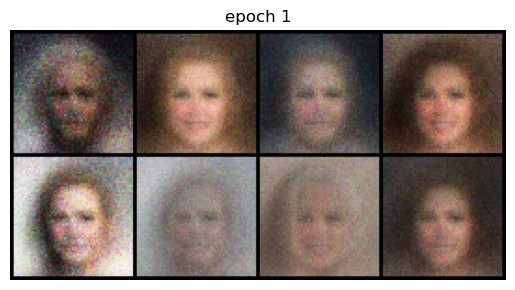

for epoch: 2/5... batch: 1... G_loss= 1.4942591190338135... D_loss= 0.3983360230922699
for epoch: 2/5... batch: 51... G_loss= 2.6762044429779053... D_loss= 0.41427627205848694
for epoch: 2/5... batch: 101... G_loss= 4.654035568237305... D_loss= 0.591828465461731
for epoch: 2/5... batch: 151... G_loss= 3.127878189086914... D_loss= 0.21073749661445618
for epoch: 2/5... batch: 201... G_loss= 3.1132383346557617... D_loss= 0.20369669795036316
for epoch: 2/5... batch: 251... G_loss= 2.8381834030151367... D_loss= 0.2597717046737671
for epoch: 2/5... batch: 301... G_loss= 2.7202091217041016... D_loss= 0.21130819618701935
for epoch: 2/5... batch: 351... G_loss= 3.4814207553863525... D_loss= 0.3859357535839081
for epoch: 2/5... batch: 401... G_loss= 1.9225622415542603... D_loss= 0.4457492232322693
for epoch: 2/5... batch: 451... G_loss= 2.8668885231018066... D_loss= 0.2682175040245056
for epoch: 2/5... batch: 501... G_loss= 3.457350730895996... D_loss= 0.314948707818985
for epoch: 2/5... batch: 

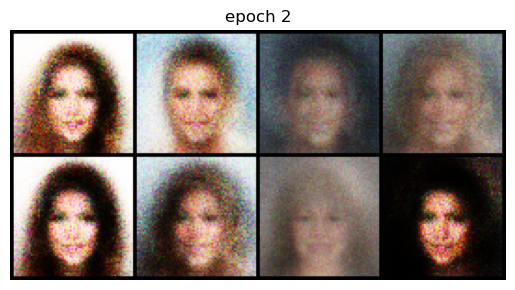

for epoch: 3/5... batch: 1... G_loss= 2.7491791248321533... D_loss= 0.285203754901886
for epoch: 3/5... batch: 51... G_loss= 3.014293670654297... D_loss= 0.310149610042572
for epoch: 3/5... batch: 101... G_loss= 3.0358428955078125... D_loss= 0.33891579508781433
for epoch: 3/5... batch: 151... G_loss= 2.3860819339752197... D_loss= 0.36184290051460266
for epoch: 3/5... batch: 201... G_loss= 2.6439785957336426... D_loss= 0.3673672378063202
for epoch: 3/5... batch: 251... G_loss= 2.4001212120056152... D_loss= 0.3593841791152954
for epoch: 3/5... batch: 301... G_loss= 2.6994099617004395... D_loss= 0.38741523027420044
for epoch: 3/5... batch: 351... G_loss= 2.7547879219055176... D_loss= 0.344093382358551
for epoch: 3/5... batch: 401... G_loss= 2.3748536109924316... D_loss= 0.3212578296661377
for epoch: 3/5... batch: 451... G_loss= 2.0379278659820557... D_loss= 0.37515097856521606
for epoch: 3/5... batch: 501... G_loss= 1.7601275444030762... D_loss= 0.48525696992874146
for epoch: 3/5... batch

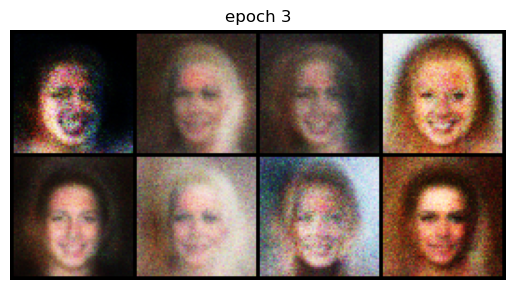

for epoch: 4/5... batch: 1... G_loss= 2.1906492710113525... D_loss= 0.3942106366157532
for epoch: 4/5... batch: 51... G_loss= 1.8325380086898804... D_loss= 0.386776864528656
for epoch: 4/5... batch: 101... G_loss= 1.7843987941741943... D_loss= 0.4939318299293518
for epoch: 4/5... batch: 151... G_loss= 1.8203879594802856... D_loss= 0.3709777593612671
for epoch: 4/5... batch: 201... G_loss= 1.9235388040542603... D_loss= 0.40550458431243896
for epoch: 4/5... batch: 251... G_loss= 2.2226345539093018... D_loss= 0.5936476588249207
for epoch: 4/5... batch: 301... G_loss= 1.7180252075195312... D_loss= 0.44847628474235535
for epoch: 4/5... batch: 351... G_loss= 2.0433523654937744... D_loss= 0.43807387351989746
for epoch: 4/5... batch: 401... G_loss= 1.8357692956924438... D_loss= 0.5125889182090759
for epoch: 4/5... batch: 451... G_loss= 2.7271718978881836... D_loss= 0.45571041107177734
for epoch: 4/5... batch: 501... G_loss= 1.8635847568511963... D_loss= 0.4604519009590149
for epoch: 4/5... bat

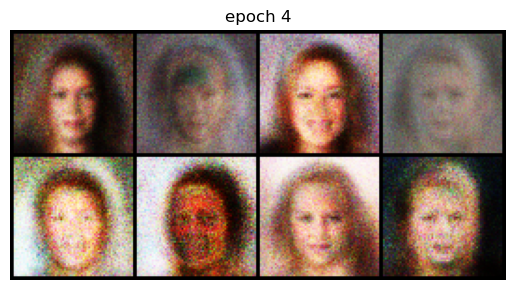

for epoch: 5/5... batch: 1... G_loss= 1.3889307975769043... D_loss= 0.500342607498169
for epoch: 5/5... batch: 51... G_loss= 1.5451622009277344... D_loss= 0.5166871547698975
for epoch: 5/5... batch: 101... G_loss= 1.6891472339630127... D_loss= 0.5497750639915466
for epoch: 5/5... batch: 151... G_loss= 1.729426383972168... D_loss= 0.4317893981933594
for epoch: 5/5... batch: 201... G_loss= 1.8520400524139404... D_loss= 0.4745860695838928
for epoch: 5/5... batch: 251... G_loss= 1.7163670063018799... D_loss= 0.5122876763343811
for epoch: 5/5... batch: 301... G_loss= 1.607958436012268... D_loss= 0.4182933270931244


In [ ]:
train(generator, discriminator, dataloader, epochs= 5)